In [ ]:
# Installing graphviz
!apt-get install graphviz -q
!pip install graphviz -q

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
## Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

import sklearn.neighbors as skl_nb
import sklearn.linear_model as skl_lm
import sklearn.discriminant_analysis as skl_da
import sklearn.model_selection as skl_ms

# Tree Based Methods
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, classification_report
import graphviz

## import the training data
url = 'https://drive.google.com/uc?export=download&id=1Aj8Nzvwg3QJNFZZBuZz4M69Rzv8Lti6y'
data = pd.read_csv(url, na_values='?').dropna()
# data.info()
# print(data)


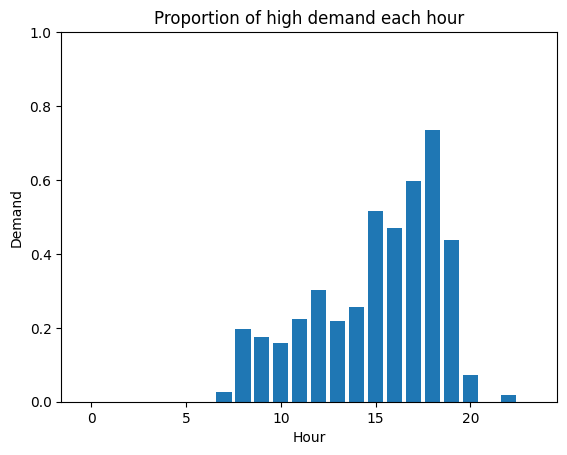

In [ ]:
## ------Plot for demand depending on hours of the day------

hour_count = {}

for h in range(0, 24):
  count_high = data[(data['hour_of_day'] == h) & (data['increase_stock'] == 'high_bike_demand')].shape[0]
  count_tot = data[(data['hour_of_day'] == h)].shape[0]
  hour_count[h] = count_high/count_tot


plt.bar(hour_count.keys(), hour_count.values())
plt.xlabel('Hour')
plt.ylabel('Demand')
plt.title('Proportion of high demand each hour')
plt.ylim(0,1)
plt.show()



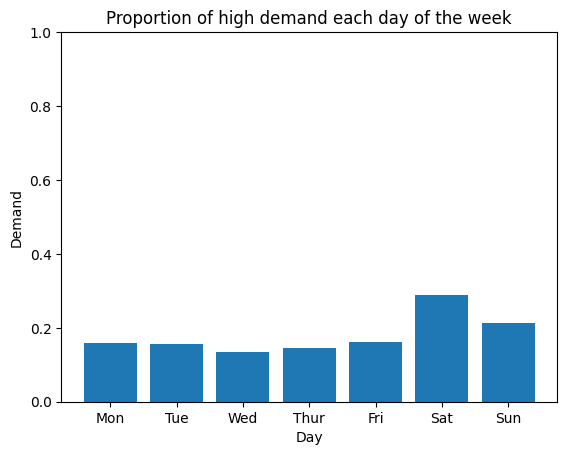

In [ ]:
## ------Plot for demand depending on days of the week------

day_count = {}

for d in range(0, 7):
  count_high = data[(data['day_of_week'] == d) & (data['increase_stock'] == 'high_bike_demand')].shape[0]
  count_tot = data[(data['day_of_week'] == d)].shape[0]
  day_count[d] = count_high/count_tot


plt.bar(day_count.keys(), day_count.values())
plt.xlabel('Day')
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['Mon', 'Tue', 'Wed', 'Thur', 'Fri', 'Sat', 'Sun'])
plt.ylabel('Demand')
plt.title('Proportion of high demand each day of the week')
plt.ylim(0, 1)
plt.show()

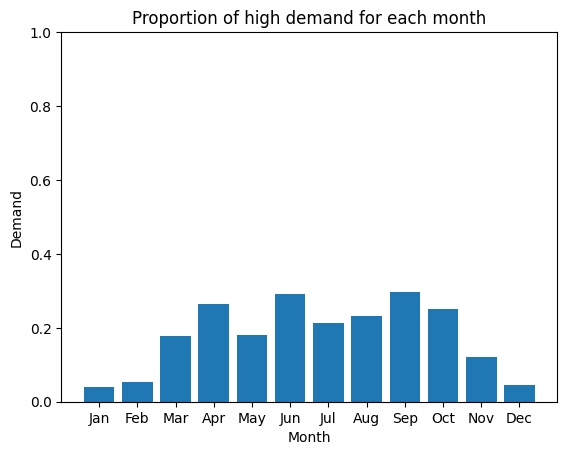

In [ ]:
## ------Plot for demand depending on the month------

month_count = {}

for m in range(1, 13):
  count_high = data[(data['month'] == m) & (data['increase_stock'] == 'high_bike_demand')].shape[0]
  count_tot = data[(data['month'] == m)].shape[0]
  month_count[m] = count_high/count_tot


plt.bar(month_count.keys(), month_count.values())
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlabel('Month')
plt.ylabel('Demand')
plt.title('Proportion of high demand for each month')
plt.ylim(0,1)
plt.show()


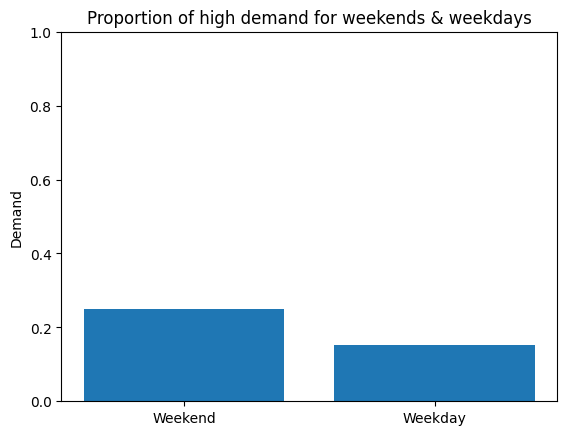

In [ ]:
## ------Plot for demand depending on weekend/weekday------

weekday_count = {}

for w in range(0, 2):
  count_high = data[(data['weekday'] == w) & (data['increase_stock'] == 'high_bike_demand')].shape[0]
  count_tot = data[(data['weekday'] == w)].shape[0]
  weekday_count[w] = count_high/count_tot


plt.bar(weekday_count.keys(), weekday_count.values())
plt.title('Proportion of high demand for weekends & weekdays')
plt.ylabel('Demand')
plt.xticks([0, 1], ['Weekend', 'Weekday'])
plt.ylim(0,1)
plt.show()





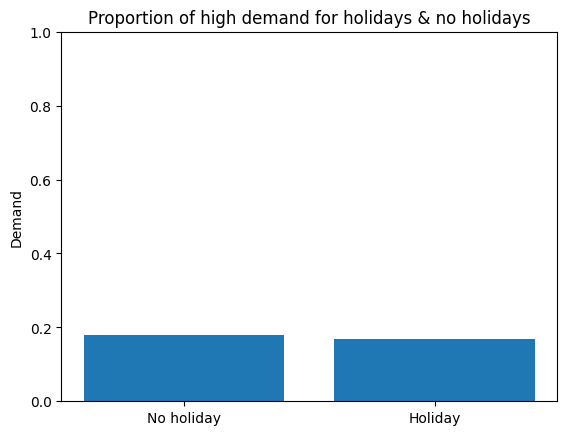

In [ ]:
## ------Plot for demand depending on holiday/no holiday------

holiday_count = {}

for h in range(0, 2):
  count_high = data[(data['holiday'] == h) & (data['increase_stock'] == 'high_bike_demand')].shape[0]
  count_tot = data[(data['holiday'] == h)].shape[0]
  holiday_count[h] = count_high/count_tot



plt.bar(holiday_count.keys(), holiday_count.values())
plt.title('Proportion of high demand for holidays & no holidays')
plt.ylabel('Demand')
plt.xticks([0, 1], ['No holiday', 'Holiday'])
plt.ylim(0,1)
plt.show()



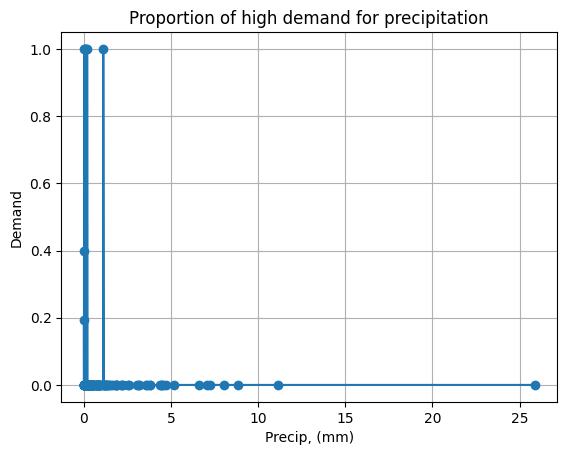

In [ ]:
## ------Plot for demand depending on precipitation------

precip_count = {}

for p in data['precip']:
  count_high = data[(data['precip'] == p) & (data['increase_stock'] == 'high_bike_demand')].shape[0]
  count_tot = data[(data['precip'] == p)].shape[0]

  precip_count[p] = count_high/count_tot

precip_count = dict(sorted(precip_count.items()))

plt.plot(precip_count.keys(), precip_count.values(), '-o')
plt.title('Proportion of high demand for precipitation')
plt.xlabel('Precip, (mm)')
plt.ylabel('Demand')
plt.grid()
plt.show()


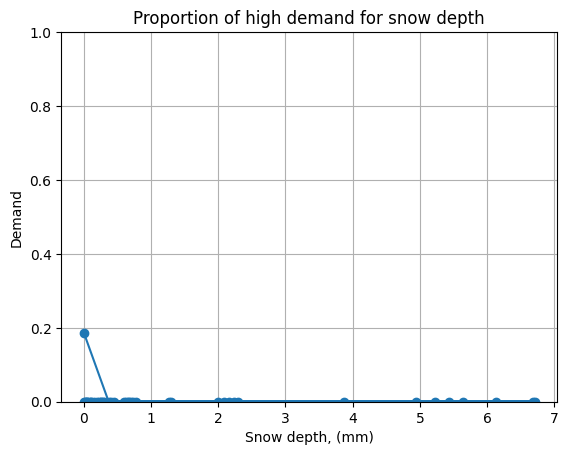

In [ ]:
## ------Plot for demand depending on snow depth------

snow_depth_count = {}

for s in data['snowdepth']:
  count_high = data[(data['snowdepth'] == s) & (data['increase_stock'] == 'high_bike_demand')].shape[0]
  count_tot = data[(data['snowdepth'] == s)].shape[0]
  snow_depth_count[s] = count_high/count_tot

precip_count = dict(sorted(precip_count.items()))

plt.plot(snow_depth_count.keys(), snow_depth_count.values(), '-o')
plt.title('Proportion of high demand for snow depth')
plt.xlabel('Snow depth, (mm)')
plt.ylabel('Demand')
plt.ylim(0,1)
plt.grid()
plt.show()


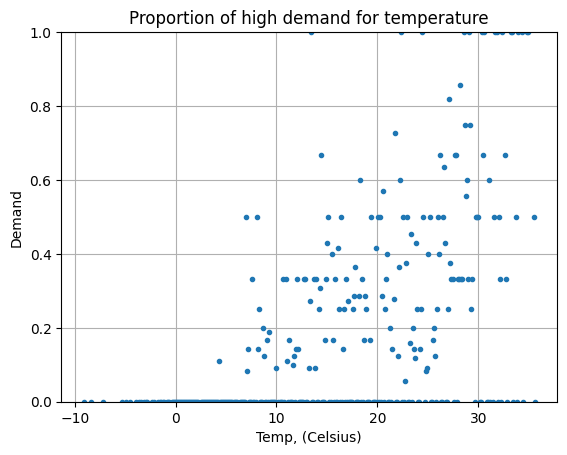

In [ ]:
## ------Plot for demand depending on snow depth------

temp_count = {}

for t in data['temp']:
  count_high = data[(data['temp'] == t) & (data['increase_stock'] == 'high_bike_demand')].shape[0]
  count_tot = data[(data['temp'] == t)].shape[0]

  temp_count[t] = count_high/count_tot

precip_count = dict(sorted(precip_count.items()))

# plt.bar(temp_count.keys(), temp_count.values(), color = 'black')
plt.plot(temp_count.keys(), temp_count.values(), '.')
plt.title('Proportion of high demand for temperature')
plt.xlabel('Temp, (Celsius)')
plt.ylabel('Demand')
plt.ylim(0,1)
plt.grid()
plt.show()


# split into training and test data set

In [ ]:
## ------Split data into training and test data------
np.random.seed(1)

trainI = np.random.choice(data.shape[0], size = 1200, replace=False)

# print(trainI[0:5])

train = data.iloc[trainI]
test = data.drop(trainI)

# print(test[0:5])

x_train = train[['hour_of_day', 'day_of_week', 'month',
                 'holiday', 'weekday', 'summertime', 'temp', 'dew',
                 'humidity', 'precip', 'snow', 'snowdepth', 'windspeed', 'cloudcover', 'visibility' ]]


x_test = test[['hour_of_day', 'day_of_week', 'month',
                 'holiday', 'weekday', 'summertime', 'temp', 'dew',
                 'humidity', 'precip', 'snow', 'snowdepth', 'windspeed', 'cloudcover', 'visibility' ]]

y_train = train['increase_stock']
y_test = test['increase_stock']

print(np.shape(x_train))


# print(x_train[0:5])

(1200, 15)


In [ ]:
# ------ Normalization and scaling of num & categ. data ------
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

n_transf = StandardScaler()
c_transf = OneHotEncoder(handle_unknown = 'ignore', sparse_output=False)

preprocessor = ColumnTransformer([
    ('numerical', n_transf, ['temp', 'dew', 'humidity', 'precip', 'snow', 'snowdepth', 'windspeed', 'cloudcover', 'visibility']),
    ('categorical', c_transf, ['hour_of_day', 'day_of_week', 'month', 'holiday', 'weekday', 'summertime'])
])

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)


# **Naive model**

In [ ]:
## ------Naive model for comparision------

## randomly selects 'high' or 'low' bike demand for each point in x_test
pred_naive = np.random.choice(['high_bike_demand', 'low_bike_demand'], size = len(x_test))

## calculate f1 score and accuracy
f1_naive = f1_score(y_test, pred_naive, pos_label='high_bike_demand')
missclassification = np.mean(pred_naive != y_test)


print(f'Accuracy: {1-missclassification}')
print(f'f1: {f1_naive:.3f}')

Accuracy: 0.48250000000000004
f1: 0.274


# **knn**


Minimum missclassification rate: 0.137
At position: 8, (corresponding to k = 9)


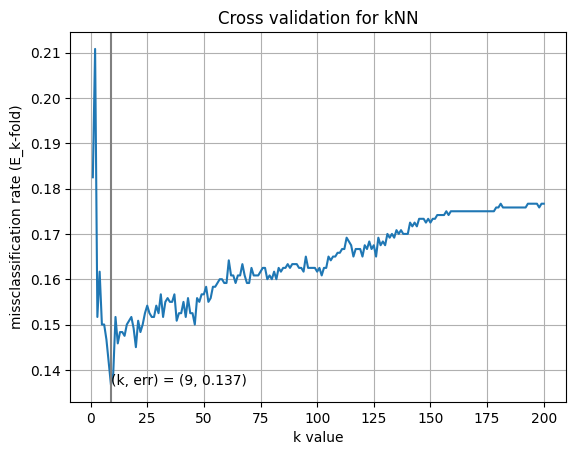

In [ ]:
## ------Implementation of kNN------
## do 10 folds
n_fold = 10

## array for storing missclassifications for 200 values of K
K = np.arange(1, 201)
missclassification = np.zeros(len(K))


## create 10 folds for cross validation
cv = skl_ms.KFold(n_splits = n_fold, random_state=1, shuffle=True)

## split the scaled data into training and validation data:
for train_index, val_index in cv.split(x_train_processed):
  X_tr, X_val = x_train_processed[train_index], x_train_processed[val_index]
  y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]


  ## for each value of k, train the model and do prediction using the validation data
  for j, k in enumerate(K):
    ## j = index
    ## k = actual k-value

    model_kNN = skl_nb.KNeighborsClassifier(n_neighbors=k)
    model_kNN.fit(X_tr, y_tr)   ## train on the training folds
    pred_kNN = model_kNN.predict(X_val) ## use val. data to do prediction
    missclassification[j] += np.mean(pred_kNN != y_val)   ## calculate number of missclassifications

## calculate average missclassification for each k
missclassification /= n_fold

missclassification = missclassification.tolist()

# min_k = missclassification.index(min(missclassification))+1
min_err = min(missclassification)
min_idx = missclassification.index(min(missclassification))


print(f'Minimum missclassification rate: {min_err:.3f}\nAt position: {min_idx}, \
(corresponding to k = {min_idx+1})')

## plot the missclassification for each k value
plt.plot(K, missclassification, label = 'missclassification for each k')
plt.title('Cross validation for kNN')
plt.xlabel('k value')
plt.ylabel('missclassification rate (E_k-fold)')
plt.text(K[min_idx], missclassification[min_idx], f'(k, err) = ({K[min_idx]}, {missclassification[min_idx]:.3f})')
plt.axvline(x = K[min_idx], color = 'grey', label = 'k value with lowest missclassification rate')
plt.grid()
plt.show()


In [ ]:
## train the model with chosen k on the entire scaled training data
k = min_idx+1
model_kNN = skl_nb.KNeighborsClassifier(n_neighbors = k)
model_kNN.fit(x_train_processed, y_train)
prediction_kNN = model_kNN.predict(x_test_processed)

## calculate the missclassification rate and f1 score
missclassification = np.mean(prediction_kNN != y_test)
f1_kNN = f1_score(y_test, prediction_kNN, pos_label='high_bike_demand')


print(f'Performance of kNN with k = {k}: \n\nMissclassification rate: {missclassification:.3f} \nAccuracy: {1-missclassification:.3f}')
print(f'f1: {f1_kNN:.3f}')

Performance of kNN with k = 9: 

Missclassification rate: 0.150 
Accuracy: 0.850
f1: 0.444


# **Logistic regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Define parameters for tuning
# Testing different C (regularisation strength) and different types of
# penalties (l1 and l2). Using solver='liblinear', supports both l1 and l2
C_options = np.logspace(-4, 4, 10)
penalties = ['l1', 'l2']
param_grid = []
for p in penalties:
    for c in C_options:
        param_grid.append({'penalty': p, 'C': c})

# 2. 10-fold cross validation
n_fold = 10
cv = skl_ms.KFold(n_splits=n_fold, shuffle=True, random_state=1)
cv_errors = np.zeros(len(param_grid))

# 3. Perform tuning
for train_index, val_index in cv.split(x_train_processed):
    # Training and validation folds
    X_tr, X_val = x_train_processed[train_index], x_train_processed[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    for i, params in enumerate(param_grid):
        # Train model for each parameter combinatoon
        model = LogisticRegression(solver='liblinear',
                                   penalty=params['penalty'],
                                   C=params['C'],
                                   max_iter=1400)
        model.fit(X_tr, y_tr)
        # misclassification rate
        pred = model.predict(X_val)
        cv_errors[i] += np.mean(pred != y_val)

# Mean error
cv_errors /= n_fold

# 4. Find the best parameters
best_idx = np.argmin(cv_errors)
best_params = param_grid[best_idx]
print(f"Best parameters: {best_params}")
print(f"Smallest cross validation error: {cv_errors[best_idx]:.4f}")

# 5. Train final model with the best parameters
log_model_tuned = LogisticRegression(solver='liblinear',
                                     penalty=best_params['penalty'],
                                     C=best_params['C'],
                                     max_iter=1400)
log_model_tuned.fit(x_train_processed, y_train)

# 6. Validation on test set
y_pred = log_model_tuned.predict(x_test_processed)
accuracy = (y_pred == y_test).mean()
f1 = f1_score(y_test, y_pred, pos_label='high_bike_demand')

print(f"\nResult on test set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Best parameters: {'penalty': 'l2', 'C': np.float64(0.3593813663804626)}
Smallest cross validation error: 0.1100

Result on test set:
Accuracy: 0.8750
F1 Score: 0.5614


# **LDA**


In [ ]:
## ------Implementation of LDA------
# 10-fold CV
n_fold = 10
cv = skl_ms.KFold(n_splits=n_fold, shuffle=True, random_state=1)

# List of parameter combinations for diff solvers
# Removed the 'eigen' solver options as they caused the LinAlgError
# The 'svd' and 'lsqr' solvers are generally more robust.
param_list = [
    {'solver': 'svd', 'shrinkage': None},
    {'solver': 'lsqr', 'shrinkage': None},
    {'solver': 'lsqr', 'shrinkage': 'auto'}
]

# For storage of average missclassification
missclassification = np.zeros(len(param_list))

#crossvalidation

for train_index, val_index in cv.split(x_train_processed):
  X_tr, X_val = x_train_processed[train_index], x_train_processed[val_index]
  y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

  for j, params in enumerate(param_list):
    model = skl_da.LinearDiscriminantAnalysis(
            solver=params['solver'],shrinkage=params['shrinkage']) #puts in different solvers and shrincages
    model.fit(X_tr, y_tr)
    y_pred_LDA = model.predict(X_val)
    missclassification[j] += np.mean(y_pred_LDA != y_val) #sums missclassification


# Mean for the folds
missclassification /= n_fold

# Find best parameter
min_err = min(missclassification)         #smallest mean missclassification
min_idx = missclassification.tolist().index(min_err)     # index of first occurance of smallest mean classification
best_params = param_list[min_idx] #The index corresponds to the order of parameters

print(f"Minimum error: {min_err:.3f}")
print(f"Best parameters: {best_params}")

Minimum error: 0.117
Best parameters: {'solver': 'lsqr', 'shrinkage': 'auto'}


Continue with LDA with chosen solver: 'solver': 'lsqr', 'shrinkage': 'auto'


In [ ]:
#train model on entire training data
model = skl_da.LinearDiscriminantAnalysis(
            solver='lsqr',shrinkage='auto')


model.fit(x_train_processed, y_train)

#predict on entire testdata
y_pred_LDA = model.predict(x_test_processed)
missclassification_LDA = np.mean(y_pred_LDA != y_test)
f1_LDA = f1_score(y_test, y_pred_LDA, pos_label='high_bike_demand')


print( f'the missclasificication of the LDA is {missclassification_LDA} and the accuracy is {1- missclassification_LDA}')
print(f'f1 score: {f1_LDA}')

the missclasificication of the LDA is 0.1275 and the accuracy is 0.8725
f1 score: 0.6046511627906976


# **Tree-based method**

Train error: 0.0000,  Test error: 0.1300


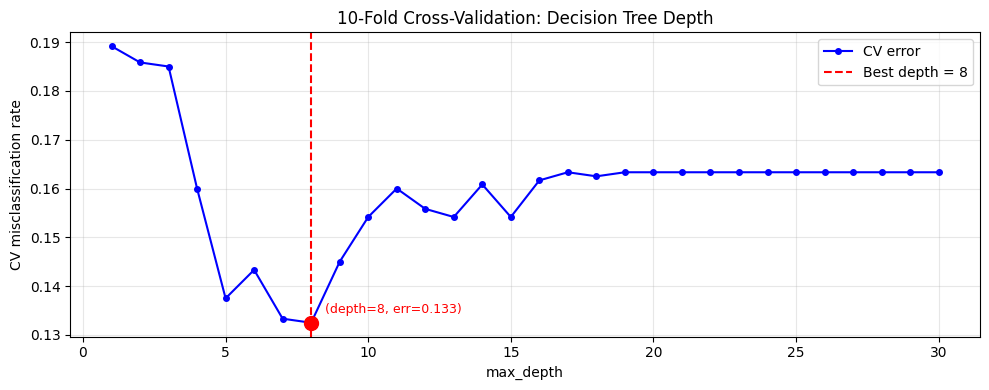

Best max_depth : 8
CV error at best depth: 0.1325  (86.8% CV accuracy)
Tuned Decision Tree
max_depth      : 8
Number of leaves: 52
Training error : 0.0525  (94.8% accuracy)
Test error     : 0.1150  (88.5% accuracy)
F1 Score (Tree - High Demand): 0.6761

Classification Report (Tree):
                  precision    recall  f1-score   support

high_bike_demand       0.69      0.67      0.68        72
 low_bike_demand       0.93      0.93      0.93       328

        accuracy                           0.89       400
       macro avg       0.81      0.80      0.80       400
    weighted avg       0.88      0.89      0.88       400


Confusion Matrix (Test Set):


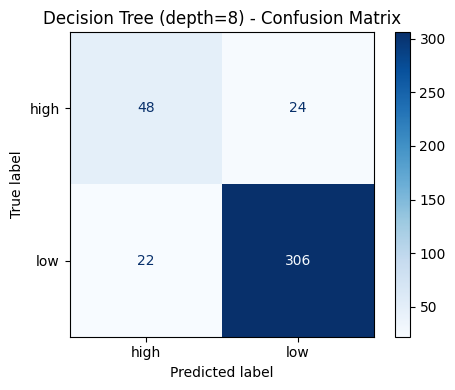

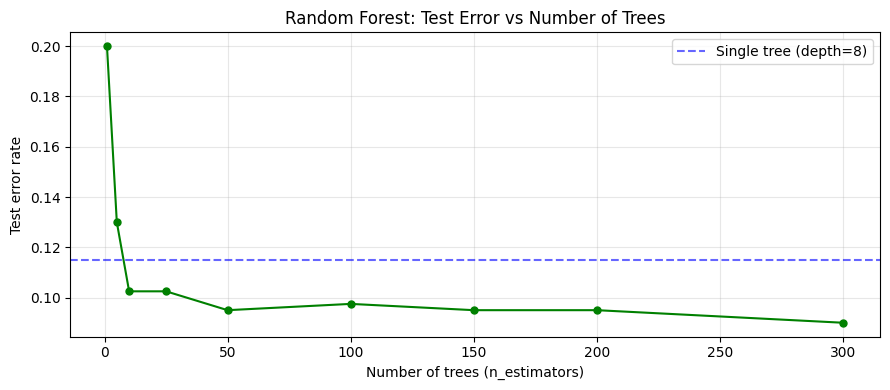

As n_estimators increases, error stabilises - diminishing returns beyond ~100 trees.


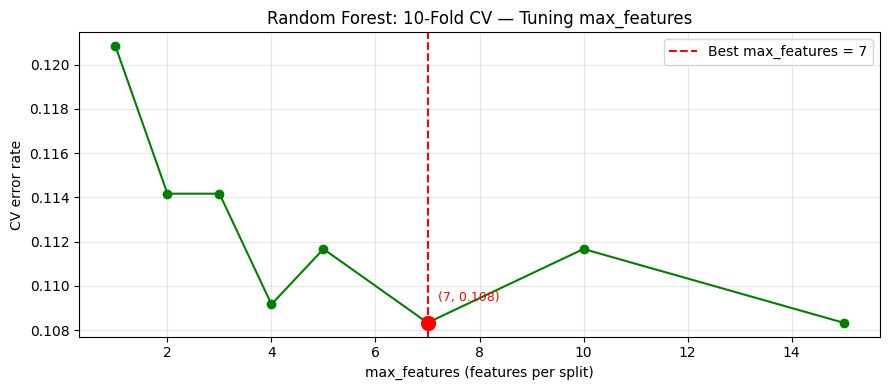

Best max_features : 7
CV error          : 0.1083
Random Forest (Tuned)
n_estimators   : 100
max_features   : 7
Training error : 0.0000  (100.0% accuracy)
Test error     : 0.0900  (91.0% accuracy)
F1 Score (Random Forest - High Demand): 0.7188

Classification Report (Random Forest):
                  precision    recall  f1-score   support

high_bike_demand       0.82      0.64      0.72        72
 low_bike_demand       0.92      0.97      0.95       328

        accuracy                           0.91       400
       macro avg       0.87      0.80      0.83       400
    weighted avg       0.91      0.91      0.91       400



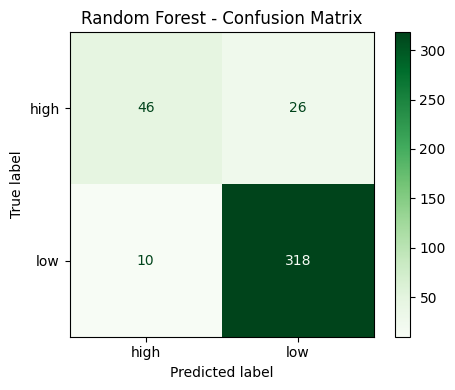

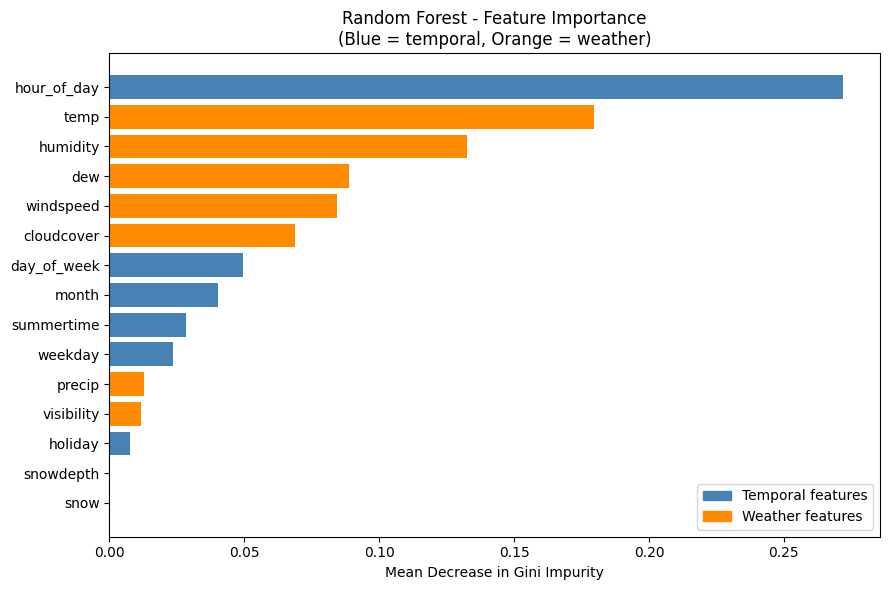

Top 5 most important features:
hour_of_day    0.272023
temp           0.179479
humidity       0.132635
dew            0.088956
windspeed      0.084407


In [ ]:
## Implementation of Tree-based methods
# first we start by creating the Baseline (Naive) Model for refference

tree_full = DecisionTreeClassifier(random_state=1)  # no depth limit
tree_full.fit(x_train, y_train)

train_err = np.mean(tree_full.predict(x_train) != y_train)
test_err  = np.mean(tree_full.predict(x_test)  != y_test)
print(f'Train error: {train_err:.4f},  Test error: {test_err:.4f}')

# Candidate depths to evaluate

depths = np.arange(1, 31)  # depths 1 to 30
n_fold = 10

cv = skl_ms.KFold(n_splits=n_fold, random_state=1, shuffle=True)
cv_errors = np.zeros(len(depths))

for train_idx, val_idx in cv.split(x_train):
    X_tr, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    for j, d in enumerate(depths):
        m = DecisionTreeClassifier(max_depth=d, random_state=1)
        m.fit(X_tr, y_tr)
        cv_errors[j] += np.mean(m.predict(X_val) != y_val)

cv_errors /= n_fold  # average over folds

best_depth = depths[np.argmin(cv_errors)]
best_cv_err = cv_errors[np.argmin(cv_errors)]

# Plot CV curve
plt.figure(figsize=(10, 4))
plt.plot(depths, cv_errors, 'b-o', markersize=4, label='CV error')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
plt.scatter(best_depth, best_cv_err, color='red', s=100, zorder=5)
plt.text(best_depth + 0.5, best_cv_err + 0.002,
         f'(depth={best_depth}, err={best_cv_err:.3f})', color='red', fontsize=9)
plt.xlabel('max_depth')
plt.ylabel('CV misclassification rate')
plt.title('10-Fold Cross-Validation: Decision Tree Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/cv_tree_depth.png', dpi=150)
plt.show()

print(f'Best max_depth : {best_depth}')
print(f'CV error at best depth: {best_cv_err:.4f}  ({(1-best_cv_err)*100:.1f}% CV accuracy)')

# Fitting the tuned tree on FULL training set

tree_tuned = DecisionTreeClassifier(max_depth=best_depth, random_state=1)
tree_tuned.fit(x_train, y_train)

y_pred_tree = tree_tuned.predict(x_test)
f1_tree = f1_score(y_test, y_pred_tree, pos_label='high_bike_demand')
train_err_tuned = np.mean(tree_tuned.predict(x_train) != y_train)
test_err_tuned  = np.mean(y_pred_tree != y_test)

print('Tuned Decision Tree')
print(f'max_depth      : {best_depth}')
print(f'Number of leaves: {tree_tuned.get_n_leaves()}')
print(f'Training error : {train_err_tuned:.4f}  ({(1-train_err_tuned)*100:.1f}% accuracy)')
print(f'Test error     : {test_err_tuned:.4f}  ({(1-test_err_tuned)*100:.1f}% accuracy)')
print(f'F1 Score (Tree - High Demand): {f1_tree:.4f}')
print("\nClassification Report (Tree):")
print(classification_report(y_test, y_pred_tree))

# Confusion matrix
print('\nConfusion Matrix (Test Set):')
cm_tree = confusion_matrix(y_test, y_pred_tree, labels=['high_bike_demand', 'low_bike_demand'])
disp = ConfusionMatrixDisplay(cm_tree, display_labels=['high', 'low'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Decision Tree (depth={best_depth}) - Confusion Matrix')
plt.tight_layout()
plt.savefig('/tmp/cm_tree.png', dpi=150)
plt.show()

# visualizing the Tuned Tree; For readability, we are visualising at most depth 4
viz_depth = min(best_depth, 4)
tree_viz = DecisionTreeClassifier(max_depth=viz_depth, random_state=1)
tree_viz.fit(x_train, y_train)

FEATURES = x_train.columns.tolist()

dot_data = tree.export_graphviz(
    tree_viz,
    out_file=None,
    feature_names=FEATURES,
    class_names=['high_bike_demand', 'low_bike_demand'],
    filled=True,
    rounded=True,
    proportion=True
)

graph = graphviz.Source(dot_data)
graph.render('/tmp/decision_tree_viz', format='png', cleanup=True)
graph

# Random Forest

# Tune number of trees: when does error stabilise?
n_trees_range = [1, 5, 10, 25, 50, 100, 150, 200, 300]
rf_test_errors = []

for n in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(x_train, y_train)
    rf_test_errors.append(np.mean(rf.predict(x_test) != y_test))

plt.figure(figsize=(9, 4))
plt.plot(n_trees_range, rf_test_errors, 'g-o', markersize=5)
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('Test error rate')
plt.title('Random Forest: Test Error vs Number of Trees')
plt.grid(True, alpha=0.3)
plt.axhline(test_err_tuned, color='blue', linestyle='--', alpha=0.6, label=f'Single tree (depth={best_depth})')
plt.legend()
plt.tight_layout()
plt.savefig('/tmp/rf_n_trees.png', dpi=150)
plt.show()
print('As n_estimators increases, error stabilises - diminishing returns beyond ~100 trees.')

# Tune max_features with 10-fold CV
# max_features controls how many features are randomly considered at each split
# sqrt(15) ≈ 4  is the standard default for classification

max_features_options = [1, 2, 3, 4, 5, 7, 10, 15]  # 15 = use all features (= bagging)
n_fold = 10
cv = skl_ms.KFold(n_splits=n_fold, random_state=1, shuffle=True)

rf_cv_errors = np.zeros(len(max_features_options))

for train_idx, val_idx in cv.split(x_train):
    X_tr, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    for j, mf in enumerate(max_features_options):
        rf_cv = RandomForestClassifier(n_estimators=100, max_features=mf, random_state=1)
        rf_cv.fit(X_tr, y_tr)
        rf_cv_errors[j] += np.mean(rf_cv.predict(X_val) != y_val)

rf_cv_errors /= n_fold

best_mf_idx = np.argmin(rf_cv_errors)
best_mf = max_features_options[best_mf_idx]

plt.figure(figsize=(9, 4))
plt.plot(max_features_options, rf_cv_errors, 'g-o', markersize=6)
plt.axvline(best_mf, color='red', linestyle='--', label=f'Best max_features = {best_mf}')
plt.scatter(best_mf, rf_cv_errors[best_mf_idx], color='red', s=100, zorder=5)
plt.text(best_mf + 0.2, rf_cv_errors[best_mf_idx] + 0.001,
         f'({best_mf}, {rf_cv_errors[best_mf_idx]:.3f})', color='red', fontsize=9)
plt.xlabel('max_features (features per split)')
plt.ylabel('CV error rate')
plt.title('Random Forest: 10-Fold CV — Tuning max_features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/rf_cv_mf.png', dpi=150)
plt.show()

print(f'Best max_features : {best_mf}')
print(f'CV error          : {rf_cv_errors[best_mf_idx]:.4f}')

# Fit final Random Forest on full training set
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_features=best_mf,
    random_state=1
)
rf_final.fit(x_train, y_train)

y_pred_rf = rf_final.predict(x_test)
f1_rf = f1_score(y_test, y_pred_rf, pos_label='high_bike_demand')
train_err_rf = np.mean(rf_final.predict(x_train) != y_train)
test_err_rf  = np.mean(y_pred_rf != y_test)

print('Random Forest (Tuned)')
print(f'n_estimators   : 100')
print(f'max_features   : {best_mf}')
print(f'Training error : {train_err_rf:.4f}  ({(1-train_err_rf)*100:.1f}% accuracy)')
print(f'Test error     : {test_err_rf:.4f}  ({(1-test_err_rf)*100:.1f}% accuracy)')
print(f'F1 Score (Random Forest - High Demand): {f1_rf:.4f}')
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['high_bike_demand', 'low_bike_demand'])
disp = ConfusionMatrixDisplay(cm_rf, display_labels=['high', 'low'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Greens')
ax.set_title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.savefig('/tmp/cm_rf.png', dpi=150)
plt.show()

# Feature Importance

importances = pd.Series(rf_final.feature_importances_, index=FEATURES)
importances_sorted = importances.sort_values(ascending=True)

# Colour bars by feature type
temporal = ['hour_of_day', 'day_of_week', 'month', 'holiday', 'weekday', 'summertime']
colors = ['steelblue' if f in temporal else 'darkorange' for f in importances_sorted.index]

plt.figure(figsize=(9, 6))
bars = plt.barh(importances_sorted.index, importances_sorted.values, color=colors)
plt.xlabel('Mean Decrease in Gini Impurity')
plt.title('Random Forest - Feature Importance\n(Blue = temporal, Orange = weather)')

# Legend
blue_patch   = mpatches.Patch(color='steelblue',  label='Temporal features')
orange_patch = mpatches.Patch(color='darkorange', label='Weather features')
plt.legend(handles=[blue_patch, orange_patch], loc='lower right')
plt.tight_layout()
plt.savefig('/tmp/feature_importance.png', dpi=150)
plt.show()

print('Top 5 most important features:')
print(importances.sort_values(ascending=False).head(5).to_string())

# **Model prediction**

In [ ]:
print ("Generating the Model Prediction")

# Importing the Data
Test_data_url = 'https://drive.google.com/uc?export=download&id=1y0-sup8TL_MrP08uw7Dj6wEilUBDrym6'
Test_data = pd.read_csv(Test_data_url)
print(f"  Shape: {Test_data.shape}")
print(f"  Features: {list(Test_data.columns)}")

# Making the prediction base our selected Random Forest model

print(f"\nUsing trained Random Forest model:")
print(f"  n_estimators: 100")
print(f"  max_features: {best_mf}")
print(f"  Model: rf_final")

Test_data_prediction = rf_final.predict(Test_data)

# Summary of our prediction
print(f"\nPrediction Summary:")
print(f"  Total predictions: {len(Test_data_prediction)}")
print(f"  Unique values: {np.unique(Test_data_prediction)}")
print(f"  High demand predictions: {np.sum(Test_data_prediction == 'high_bike_demand')}")
print(f"  Low demand predictions: {np.sum(Test_data_prediction == 'low_bike_demand')}")
print(f"  Proportion high demand: {np.mean(Test_data_prediction == 'high_bike_demand'):.1%}")

# Converting string labels to binary format
# 'high_bike_demand' to 1, 'low_bike_demand' to 0
predictions_binary = [1 if pred == 'high_bike_demand' else 0 for pred in Test_data_prediction]

print(f"\nConverted to binary (1=high, 0=low):")
print(f"  High (1): {sum(predictions_binary)}")
print(f"  Low (0): {len(predictions_binary) - sum(predictions_binary)}")
print(f"  First 20: {predictions_binary[:20]}")
print(f"  Last 20: {predictions_binary[-20:]}")

np.savetxt('predictions.csv', [predictions_binary], delimiter=',', fmt='%d')

Generating the Model Prediction
  Shape: (400, 15)
  Features: ['hour_of_day', 'day_of_week', 'month', 'holiday', 'weekday', 'summertime', 'temp', 'dew', 'humidity', 'precip', 'snow', 'snowdepth', 'windspeed', 'cloudcover', 'visibility']

Using trained Random Forest model:
  n_estimators: 100
  max_features: 7
  Model: rf_final

Prediction Summary:
  Total predictions: 400
  Unique values: ['high_bike_demand' 'low_bike_demand']
  High demand predictions: 54
  Low demand predictions: 346
  Proportion high demand: 13.5%

Converted to binary (1=high, 0=low):
  High (1): 54
  Low (0): 346
  First 20: [0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0]
  Last 20: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]


# **Comparision between models**

# Boxplots for cross-validation of chosen models

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

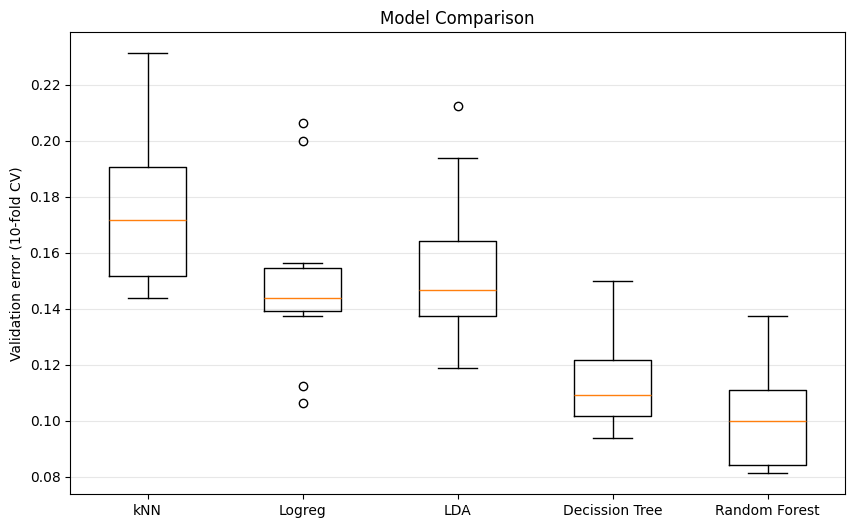

In [ ]:
## ------Boxplot for cross-validation comparison of chosen models------
n_fold = 10

x = data.drop(columns = ['increase_stock'])
y = data['increase_stock']

models = []
models.append(skl_nb.KNeighborsClassifier(n_neighbors = k))
models.append(LogisticRegression(solver='lbfgs', max_iter=1400))
models.append(skl_da.LinearDiscriminantAnalysis(solver='svd', shrinkage=None))

models.append(DecisionTreeClassifier(max_depth=8, random_state=1))
models.append(RandomForestClassifier(n_estimators=100, max_features=7, random_state=1))

# Initialize the error matrix - size is (10 folds, 5 models)
missclassification = np.zeros((n_fold, len(models)))

cv = skl_ms.KFold(n_splits = n_fold, random_state = 1, shuffle = True)

for i, (train_index, val_index) in enumerate(cv.split(x)):
    X_train_cv, X_val_cv = x.iloc[train_index], x.iloc[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    for m in range(len(models)):
        model = models[m]
        model.fit(X_train_cv, y_train_cv)
        prediction = model.predict(X_val_cv)
        missclassification[i, m] = np.mean(prediction != y_val_cv)

# PLOT FOR 5 MODELS
plt.figure(figsize=(10, 6))
plt.boxplot(missclassification)
plt.xticks(np.arange(5)+1, ('kNN', 'Logreg', 'LDA', 'Decission Tree', 'Random Forest'))
plt.ylabel('Validation error (10-fold CV)')
plt.title('Model Comparison')
plt.grid(axis='y', alpha=0.3)
plt.show()
